# VCG 2-Agent Truthfulness Analysis (k=25, Batch Averaging)

**Approach:** Generate 25 samples per bid combination. Group into 5 batches of 5.
For each batch, select the welfare-maximizing sample. Then average the alignment
scores across the 5 batch winners.

For VCG, the deviating agent's payment is computed from the OPPONENT's allocation:
  p_vcg(b_self) = b_other * [x_opp(0, b_other) - x_opp(b_self, b_other)]
Utility: u(v, b) = v * x_self(b) - p_vcg(b).


In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import interpolate
from collections import defaultdict

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_DIR = '../results/truthfulness_vcg_25'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Batch configuration
NUM_BATCHES = 5
BATCH_SIZE = 5  # samples per batch
TOTAL_SAMPLES = NUM_BATCHES * BATCH_SIZE  # 25
print(f'Batch config: {NUM_BATCHES} batches x {BATCH_SIZE} samples = {TOTAL_SAMPLES} total')


Batch config: 5 batches x 5 samples = 25 total


## 1. Load Alignment Data

In [2]:
def load_alignment_data(alignment_dir, prompts_path, prompt_indices=None):
    """Load all alignment JSONs from a directory.
    
    Returns a DataFrame with columns:
        prompt_idx, b1, b2, sample_idx, base_alignment,
        agent1_alignment, agent2_alignment, total_welfare, weighted_alignment
    """
    if not os.path.exists(alignment_dir):
        print(f'Alignment dir not found: {alignment_dir}')
        return pd.DataFrame()
    
    with open(prompts_path) as f:
        prompts = json.load(f)
    
    if prompt_indices is None:
        prompt_indices = list(range(len(prompts)))
    
    records = []
    for prompt_idx in prompt_indices:
        prompt_dir = os.path.join(alignment_dir, f'prompt_{prompt_idx:03d}')
        if not os.path.isdir(prompt_dir):
            print(f'  Skipping prompt {prompt_idx} (not found)')
            continue
        
        json_files = glob.glob(os.path.join(prompt_dir, 'alignment_*.json'))
        if not json_files:
            print(f'  Skipping prompt {prompt_idx} (no alignment files)')
            continue
        
        for json_file in json_files:
            with open(json_file) as f:
                data = json.load(f)
            
            meta = data['metadata']
            bids = meta['bids']
            scores = data['alignment_scores']
            welfare = data['welfare_metrics']
            
            records.append({
                'prompt_idx': meta['prompt_index'],
                'b1': bids[0],
                'b2': bids[1],
                'sample_idx': meta['sample_index'],
                'base_alignment': scores['base_alignment'],
                'agent1_alignment': scores['agent1_alignment'],
                'agent2_alignment': scores['agent2_alignment'],
                'total_welfare': welfare['total_welfare'],
                'weighted_alignment': welfare['weighted_alignment'],
                'base_prompt': prompts[meta['prompt_index']]['base_prompt'],
                'agent1_prompt': prompts[meta['prompt_index']]['agent1_prompt'],
                'agent2_prompt': prompts[meta['prompt_index']]['agent2_prompt'],
            })
    
    df = pd.DataFrame(records)
    if len(df) > 0:
        print(f'Loaded {len(df)} alignment records from {alignment_dir}')
        sample_counts = df.groupby(['prompt_idx', 'b1', 'b2']).size()
        print(f'  Prompts: {sorted(df.prompt_idx.unique())}')
        print(f'  Bid combos: {len(sample_counts)}')
        print(f'  Samples per combo: min={sample_counts.min()}, max={sample_counts.max()}, median={sample_counts.median()}')
    else:
        print(f'No alignment data found in {alignment_dir}')
    return df


In [3]:
# Load data for prompts 2 and 3 (only ones with full k=25 data)
df_regular = load_alignment_data(
    '../alignment/truthfulness_clip_regular',
    '../prompts/truthfulness_regular.json',
    prompt_indices=[2, 3]
)

HAS_DATA = len(df_regular) > 0
if HAS_DATA:
    sample_dist = df_regular.groupby(['prompt_idx', 'b1', 'b2']).size()
    print(f'\nSample count distribution:')
    print(sample_dist.value_counts().sort_index())
    n_complete = (sample_dist >= TOTAL_SAMPLES).sum()
    print(f'\nBid combos with >= {TOTAL_SAMPLES} samples: {n_complete}/{len(sample_dist)}')


Loaded 5850 alignment records from ../alignment/truthfulness_clip_regular
  Prompts: [2, 3]
  Bid combos: 234
  Samples per combo: min=25, max=25, median=25.0

Sample count distribution:
25    234
Name: count, dtype: int64

Bid combos with >= 25 samples: 234/234


## 2. Batch Welfare-Optimal Averaging

In [4]:
def batch_welfare_average(df, num_batches=5, batch_size=5):
    """For each (prompt_idx, b1, b2), split samples into batches,
    pick welfare-optimal from each batch, and average alignments.
    Only includes bid combos with FULL k=25 data.
    """
    if len(df) == 0:
        return df
    
    total_needed = num_batches * batch_size
    records = []
    skipped = 0
    
    for (pidx, b1, b2), group in df.groupby(['prompt_idx', 'b1', 'b2']):
        group_sorted = group.sort_values('sample_idx').reset_index(drop=True)
        
        if len(group_sorted) < total_needed:
            skipped += 1
            continue
        else:
            n_complete_batches = num_batches
        
        batch_winners_a1 = []
        batch_winners_a2 = []
        batch_winners_base = []
        
        for batch_i in range(n_complete_batches):
            start = batch_i * batch_size
            end = start + batch_size
            batch = group_sorted.iloc[start:end]
            
            best_idx = batch['total_welfare'].idxmax()
            winner = batch.loc[best_idx]
            
            batch_winners_a1.append(winner['agent1_alignment'])
            batch_winners_a2.append(winner['agent2_alignment'])
            batch_winners_base.append(winner['base_alignment'])
        
        records.append({
            'prompt_idx': pidx,
            'b1': b1,
            'b2': b2,
            'agent1_alignment': np.mean(batch_winners_a1),
            'agent2_alignment': np.mean(batch_winners_a2),
            'base_alignment': np.mean(batch_winners_base),
            'agent1_alignment_std': np.std(batch_winners_a1),
            'agent2_alignment_std': np.std(batch_winners_a2),
            'agent1_batch_vals': list(batch_winners_a1),
            'agent2_batch_vals': list(batch_winners_a2),
            'n_batches': n_complete_batches,
        })
    
    result = pd.DataFrame(records)
    print(f'Batch-averaged {len(result)} bid combos ({skipped} skipped for < {total_needed} samples)')
    if len(result) > 0:
        print(f'  Batches used: {result["n_batches"].value_counts().to_dict()}')
    return result

if HAS_DATA:
    df_avg = batch_welfare_average(df_regular, NUM_BATCHES, BATCH_SIZE)
    print(f'\nResult: {len(df_avg)} averaged allocation points')
else:
    df_avg = pd.DataFrame()


Batch-averaged 234 bid combos (0 skipped for < 25 samples)
  Batches used: {5: 234}

Result: 234 averaged allocation points


## 3. Bid grids and constants

In [5]:
# Fine bid grid (0.05 increments)
FIXED_VALUES = [0.3, 0.5, 0.7]
ALL_BIDS = np.sort(np.unique(np.concatenate([np.arange(0.0, 1.05, 0.05).round(2)])))

# True values for regret computation
REGRET_TRUE_VALUES = np.round(np.arange(0.1, 1.0, 0.1), 2)
# Finer grid for plotting
FINE_TV = np.round(np.arange(0.05, 1.0, 0.05), 2)

print(f'All bids ({len(ALL_BIDS)}): {ALL_BIDS}')
print(f'Fixed opponent values: {FIXED_VALUES}')
print(f'Regret true values ({len(REGRET_TRUE_VALUES)}): {REGRET_TRUE_VALUES}')
print(f'Fine plotting true values ({len(FINE_TV)}): {FINE_TV}')


All bids (21): [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
Fixed opponent values: [0.3, 0.5, 0.7]
Regret true values (9): [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
Fine plotting true values (19): [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


## 4. Build Allocation Curves (self) and Opponent Curves

In [6]:
def build_allocation_curves(df_avg, agent_col, vary_col, fixed_col, min_points=5, bid_subset='all'):
    """Build allocation curves from batch-averaged data."""
    curves = {}
    if len(df_avg) == 0:
        return curves
    
    std_col = agent_col + '_std'
    batch_col = agent_col.replace('_alignment', '_batch_vals')
    
    for prompt_idx in df_avg['prompt_idx'].unique():
        for fixed_val in FIXED_VALUES:
            mask = (df_avg['prompt_idx'] == prompt_idx) & (np.isclose(df_avg[fixed_col], fixed_val))
            subset = df_avg[mask].sort_values(vary_col)
            
            if len(subset) < min_points:
                continue
            
            bids = subset[vary_col].values
            allocations = subset[agent_col].values
            stds = subset[std_col].values if std_col in subset.columns else np.zeros_like(allocations)
            
            interp_fn = interpolate.interp1d(
                bids, allocations, kind='linear',
                fill_value='extrapolate', bounds_error=False
            )
            
            batch_interp_fns = []
            if batch_col in subset.columns:
                batch_vals_list = subset[batch_col].tolist()
                n_batches = len(batch_vals_list[0]) if batch_vals_list else 0
                for bi in range(n_batches):
                    batch_allocs = np.array([bv[bi] for bv in batch_vals_list])
                    batch_fn = interpolate.interp1d(
                        bids, batch_allocs, kind='linear',
                        fill_value='extrapolate', bounds_error=False
                    )
                    batch_interp_fns.append(batch_fn)
            
            curves[(prompt_idx, fixed_val)] = {
                'bids': bids,
                'allocations': allocations,
                'stds': stds,
                'interp_fn': interp_fn,
                'batch_interp_fns': batch_interp_fns,
            }
    
    return curves


In [7]:
def build_opponent_curves(df_avg, deviator_col, opp_alignment_col, fixed_col, min_points=5):
    """For each (prompt_idx, fixed_val), build interpolator for the OPPONENT's alignment
    vs the deviating agent's bid. Used inside VCG payment computation.

    Args:
        df_avg: batch-averaged DataFrame
        deviator_col: 'b1' if agent 1 is deviating, 'b2' if agent 2 is deviating
        opp_alignment_col: 'agent2_alignment' if agent 1 deviating, else 'agent1_alignment'
        fixed_col: 'b2' if agent 1 deviating, 'b1' if agent 2 deviating

    Returns: dict {(prompt_idx, fixed_val): {'interp_fn': callable, 'batch_interp_fns': [callables]}}
    """
    curves = {}
    if len(df_avg) == 0:
        return curves
    batch_col = opp_alignment_col.replace('_alignment', '_batch_vals')
    for prompt_idx in df_avg['prompt_idx'].unique():
        for fv in FIXED_VALUES:
            mask = (df_avg['prompt_idx'] == prompt_idx) & (np.isclose(df_avg[fixed_col], fv))
            sub = df_avg[mask].sort_values(deviator_col)
            if len(sub) < min_points:
                continue
            bids = sub[deviator_col].values
            opp_allocs = sub[opp_alignment_col].values
            interp_fn = interpolate.interp1d(bids, opp_allocs, kind='linear',
                                              fill_value='extrapolate', bounds_error=False)
            batch_fns = []
            if batch_col in sub.columns:
                bv_list = sub[batch_col].tolist()
                n_b = len(bv_list[0]) if bv_list else 0
                for bi in range(n_b):
                    batch_allocs = np.array([bv[bi] for bv in bv_list])
                    batch_fns.append(interpolate.interp1d(bids, batch_allocs, kind='linear',
                                                          fill_value='extrapolate', bounds_error=False))
            curves[(prompt_idx, fv)] = {'interp_fn': interp_fn, 'batch_interp_fns': batch_fns,
                                         'bids': bids, 'allocations': opp_allocs}
    return curves

if HAS_DATA and len(df_avg) > 0:
    # Self allocation curves (deviating agent's own alignment)
    curves_a1 = build_allocation_curves(df_avg, 'agent1_alignment', 'b1', 'b2', bid_subset='all')
    curves_a2 = build_allocation_curves(df_avg, 'agent2_alignment', 'b2', 'b1', bid_subset='all')
    # Opponent allocation curves (other agent's alignment vs. self bid)
    opp_curves_a1 = build_opponent_curves(df_avg, deviator_col='b1', opp_alignment_col='agent2_alignment', fixed_col='b2')
    opp_curves_a2 = build_opponent_curves(df_avg, deviator_col='b2', opp_alignment_col='agent1_alignment', fixed_col='b1')
    print(f'Self curves a1: {len(curves_a1)}, a2: {len(curves_a2)}')
    print(f'Opponent curves a1: {len(opp_curves_a1)}, a2: {len(opp_curves_a2)}')
    for k in sorted(curves_a1.keys()):
        print(f'  a1 {k}: {len(curves_a1[k]["bids"])} pts, {len(curves_a1[k]["batch_interp_fns"])} batch fns')
else:
    curves_a1, curves_a2 = {}, {}
    opp_curves_a1, opp_curves_a2 = {}, {}
    print('No data to build curves')


Self curves a1: 6, a2: 6
Opponent curves a1: 6, a2: 6
  a1 (2, 0.3): 21 pts, 5 batch fns
  a1 (2, 0.5): 21 pts, 5 batch fns
  a1 (2, 0.7): 21 pts, 5 batch fns
  a1 (3, 0.3): 21 pts, 5 batch fns
  a1 (3, 0.5): 21 pts, 5 batch fns
  a1 (3, 0.7): 21 pts, 5 batch fns


## 5. VCG Payment & Utility Functions

In [8]:
def compute_vcg_payment_2agent(opp_interp_fn, b_self, b_other_fixed):
    """VCG payment for the deviating agent.
    p_vcg(b_self) = b_other * [x_opp(0, b_other) - x_opp(b_self, b_other)]
    Both terms read from opp_interp_fn. Clamped to >= 0.
    """
    opp_at_zero = float(opp_interp_fn(0.0))
    opp_at_self = float(opp_interp_fn(b_self))
    return max(b_other_fixed * (opp_at_zero - opp_at_self), 0.0)


def compute_vcg_utility(true_value, b_self, b_other_fixed, alloc_fn, opp_interp_fn):
    """u(v, b) = v * x_self(b) - p_vcg(b)."""
    x_self = float(alloc_fn(b_self))
    p = compute_vcg_payment_2agent(opp_interp_fn, b_self, b_other_fixed)
    return true_value * x_self - p


def compute_vcg_regret_curve(alloc_fn, opp_interp_fn, b_other_fixed,
                              true_values=None, bid_grid=None):
    """Compute relative regret using VCG payment for each true value."""
    if true_values is None:
        true_values = REGRET_TRUE_VALUES
    if bid_grid is None:
        bid_grid = ALL_BIDS
    rows = []
    for v in true_values:
        u_truthful = compute_vcg_utility(v, v, b_other_fixed, alloc_fn, opp_interp_fn)
        utilities = [compute_vcg_utility(v, b, b_other_fixed, alloc_fn, opp_interp_fn) for b in bid_grid]
        best_idx = int(np.argmax(utilities))
        u_optimal = utilities[best_idx]
        b_optimal = float(bid_grid[best_idx])
        if abs(u_truthful) > 1e-10:
            rel = (u_optimal - u_truthful) / abs(u_truthful)
        else:
            rel = 0.0 if abs(u_optimal - u_truthful) < 1e-10 else np.inf
        rows.append({'true_value': v, 'truthful_utility': u_truthful,
                     'optimal_utility': u_optimal, 'optimal_bid': b_optimal,
                     'relative_regret': rel})
    return pd.DataFrame(rows)


## 6. Per-prompt plots: allocation (top) + regret (bottom)

Saved ../results/truthfulness_vcg_25/vcg_regret_mean_a1.png


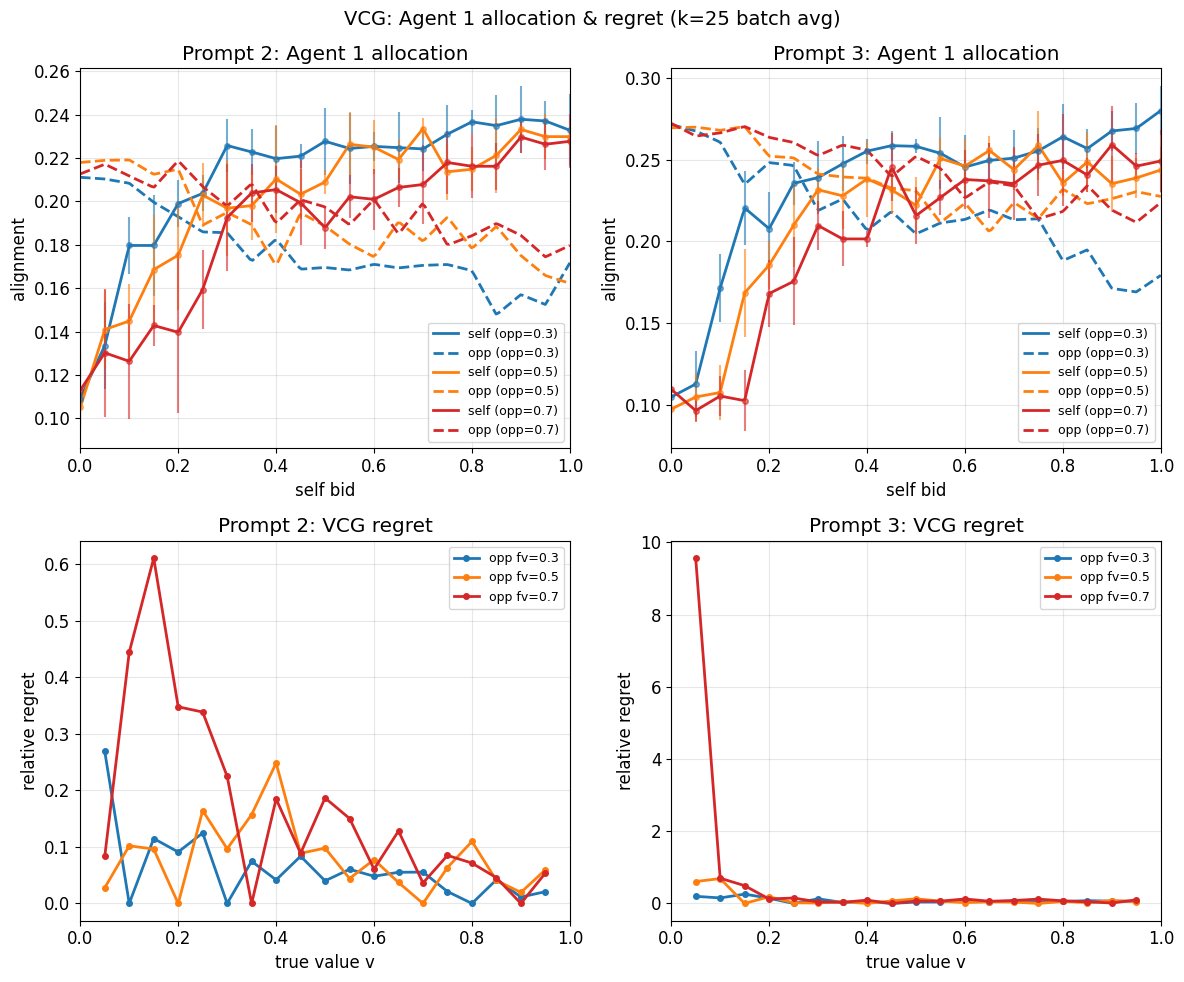

Saved ../results/truthfulness_vcg_25/vcg_regret_mean_a2.png


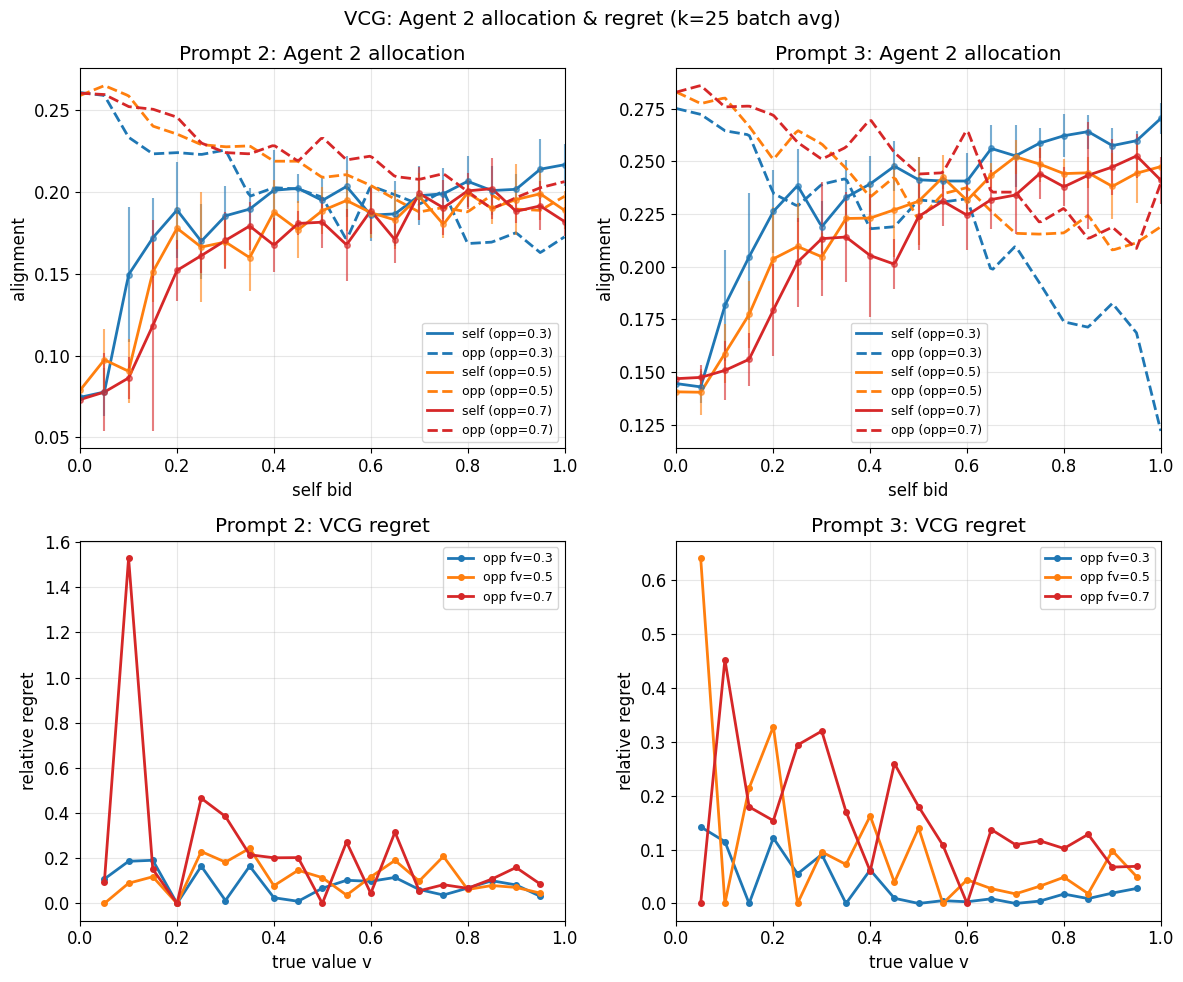

In [9]:
def plot_vcg_regret_mean(self_curves, opp_curves, agent_name, save_name):
    """Per-prompt panels. Top = allocation (self solid + opp dashed), bottom = regret."""
    if not self_curves or not opp_curves:
        print(f'No curves for {agent_name}')
        return None
    prompt_indices = sorted(set(k[0] for k in self_curves.keys()))
    colors = {0.3: 'tab:blue', 0.5: 'tab:orange', 0.7: 'tab:red'}
    n_cols = len(prompt_indices)
    fig, axes = plt.subplots(2, n_cols, figsize=(6*n_cols, 10), squeeze=False)
    fine_bids = np.linspace(0, 1, 200)
    
    for col, pidx in enumerate(prompt_indices):
        ax_alloc = axes[0, col]
        ax_reg = axes[1, col]
        for fv in FIXED_VALUES:
            key = (pidx, fv)
            if key not in self_curves or key not in opp_curves:
                continue
            color = colors[fv]
            self_data = self_curves[key]
            opp_data = opp_curves[key]
            
            # Allocation plot
            ax_alloc.plot(fine_bids, self_data['interp_fn'](fine_bids), color=color, linewidth=2,
                          label=f'self (opp={fv})')
            ax_alloc.errorbar(self_data['bids'], self_data['allocations'], yerr=self_data['stds'],
                              fmt='o', color=color, markersize=4, alpha=0.6)
            ax_alloc.plot(fine_bids, opp_data['interp_fn'](fine_bids), color=color, linewidth=2,
                          linestyle='--', label=f'opp (opp={fv})')
            
            # Regret curve
            regret_df = compute_vcg_regret_curve(self_data['interp_fn'], opp_data['interp_fn'],
                                                  b_other_fixed=fv, true_values=FINE_TV,
                                                  bid_grid=ALL_BIDS)
            ax_reg.plot(regret_df['true_value'], regret_df['relative_regret'],
                        color=color, linewidth=2, marker='o', markersize=4,
                        label=f'opp fv={fv}')
        
        ax_alloc.set_title(f'Prompt {pidx}: {agent_name} allocation')
        ax_alloc.set_xlabel('self bid')
        ax_alloc.set_ylabel('alignment')
        ax_alloc.set_xlim(0, 1)
        ax_alloc.legend(fontsize=9)
        
        ax_reg.set_title(f'Prompt {pidx}: VCG regret')
        ax_reg.set_xlabel('true value v')
        ax_reg.set_ylabel('relative regret')
        ax_reg.set_xlim(0, 1)
        # auto-scaled y-axis
        ax_reg.legend(fontsize=9)
    
    fig.suptitle(f'VCG: {agent_name} allocation & regret (k=25 batch avg)', fontsize=14)
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, save_name)
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()
    return fig

if HAS_DATA and len(df_avg) > 0:
    plot_vcg_regret_mean(curves_a1, opp_curves_a1, 'Agent 1', 'vcg_regret_mean_a1.png')
    plot_vcg_regret_mean(curves_a2, opp_curves_a2, 'Agent 2', 'vcg_regret_mean_a2.png')


## 7. Mean across prompts: allocation (left) + regret (right)

Saved ../results/truthfulness_vcg_25/vcg_regret_mean_across_a1.png


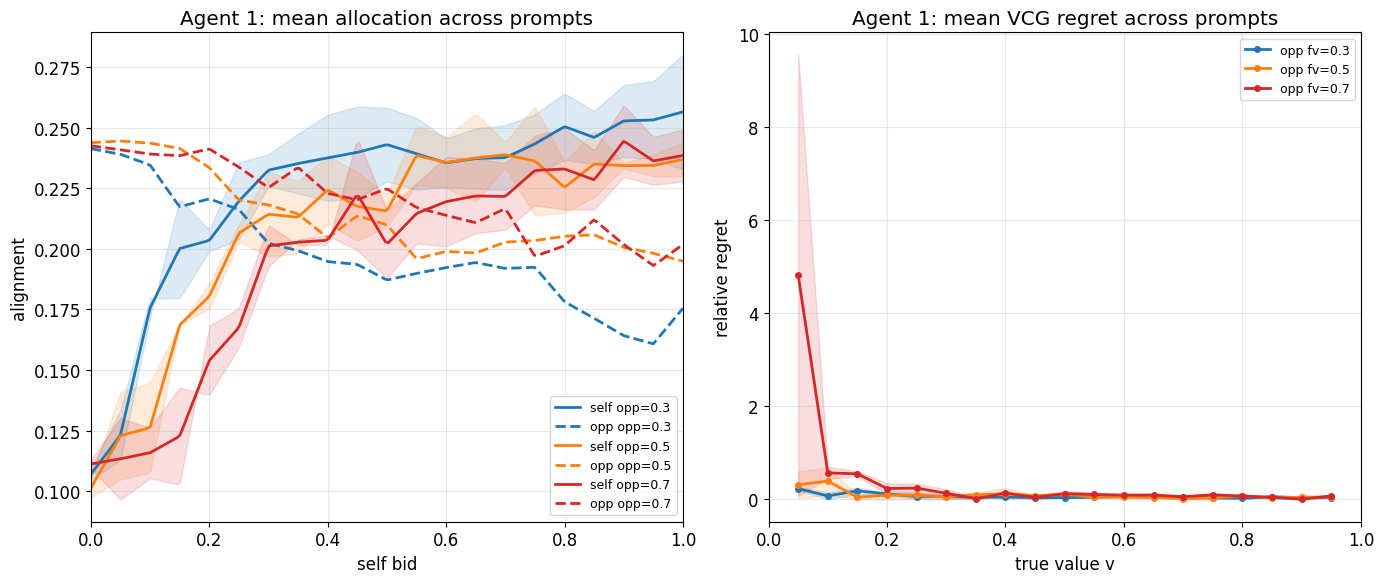

Saved ../results/truthfulness_vcg_25/vcg_regret_mean_across_a2.png


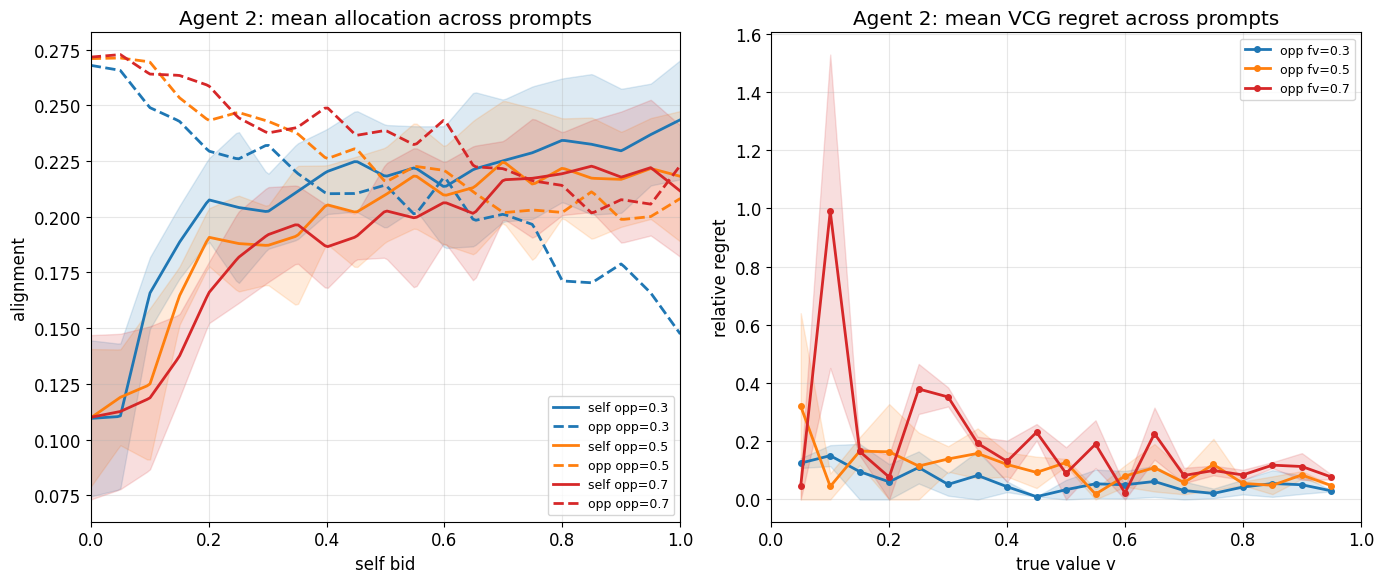

In [10]:
def plot_vcg_regret_mean_across_prompts(self_curves, opp_curves, agent_name, save_name):
    """1x2 figure. Left = mean allocation (self solid + opp dashed). Right = mean regret."""
    if not self_curves or not opp_curves:
        print(f'No curves for {agent_name}')
        return None
    fig, (ax_alloc, ax_reg) = plt.subplots(1, 2, figsize=(14, 6))
    colors = {0.3: 'tab:blue', 0.5: 'tab:orange', 0.7: 'tab:red'}
    fine_bids = np.linspace(0, 1, 200)
    
    for fv in FIXED_VALUES:
        color = colors[fv]
        # Allocation
        keys = [k for k in self_curves if k[1] == fv and k in opp_curves]
        if not keys:
            continue
        self_allocs = np.array([self_curves[k]['interp_fn'](fine_bids) for k in keys])
        opp_allocs = np.array([opp_curves[k]['interp_fn'](fine_bids) for k in keys])
        ax_alloc.plot(fine_bids, self_allocs.mean(axis=0), color=color, linewidth=2,
                      label=f'self opp={fv}')
        ax_alloc.fill_between(fine_bids, self_allocs.mean(axis=0)-self_allocs.std(axis=0),
                              self_allocs.mean(axis=0)+self_allocs.std(axis=0), color=color, alpha=0.15)
        ax_alloc.plot(fine_bids, opp_allocs.mean(axis=0), color=color, linewidth=2,
                      linestyle='--', label=f'opp opp={fv}')
        
        # Regret: average across prompts
        regret_per_prompt = []
        for k in keys:
            self_data = self_curves[k]
            opp_data = opp_curves[k]
            rdf = compute_vcg_regret_curve(self_data['interp_fn'], opp_data['interp_fn'],
                                            b_other_fixed=fv, true_values=FINE_TV,
                                            bid_grid=ALL_BIDS)
            regret_per_prompt.append(rdf['relative_regret'].values)
        regret_per_prompt = np.array(regret_per_prompt)
        mean_reg = regret_per_prompt.mean(axis=0)
        std_reg = regret_per_prompt.std(axis=0)
        ax_reg.plot(FINE_TV, mean_reg, color=color, linewidth=2, marker='o', markersize=4,
                    label=f'opp fv={fv}')
        ax_reg.fill_between(FINE_TV, mean_reg-std_reg, mean_reg+std_reg, color=color, alpha=0.15)
    
    ax_alloc.set_title(f'{agent_name}: mean allocation across prompts')
    ax_alloc.set_xlabel('self bid')
    ax_alloc.set_ylabel('alignment')
    ax_alloc.set_xlim(0, 1)
    ax_alloc.legend(fontsize=9)
    
    ax_reg.set_title(f'{agent_name}: mean VCG regret across prompts')
    ax_reg.set_xlabel('true value v')
    ax_reg.set_ylabel('relative regret')
    ax_reg.set_xlim(0, 1)
    # auto-scaled y-axis
    ax_reg.legend(fontsize=9)
    
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, save_name)
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()
    return fig

if HAS_DATA and len(df_avg) > 0:
    plot_vcg_regret_mean_across_prompts(curves_a1, opp_curves_a1, 'Agent 1', 'vcg_regret_mean_across_a1.png')
    plot_vcg_regret_mean_across_prompts(curves_a2, opp_curves_a2, 'Agent 2', 'vcg_regret_mean_across_a2.png')


## 8. Per-batch regret curves

Saved ../results/truthfulness_vcg_25/vcg_regret_batch_a1.png


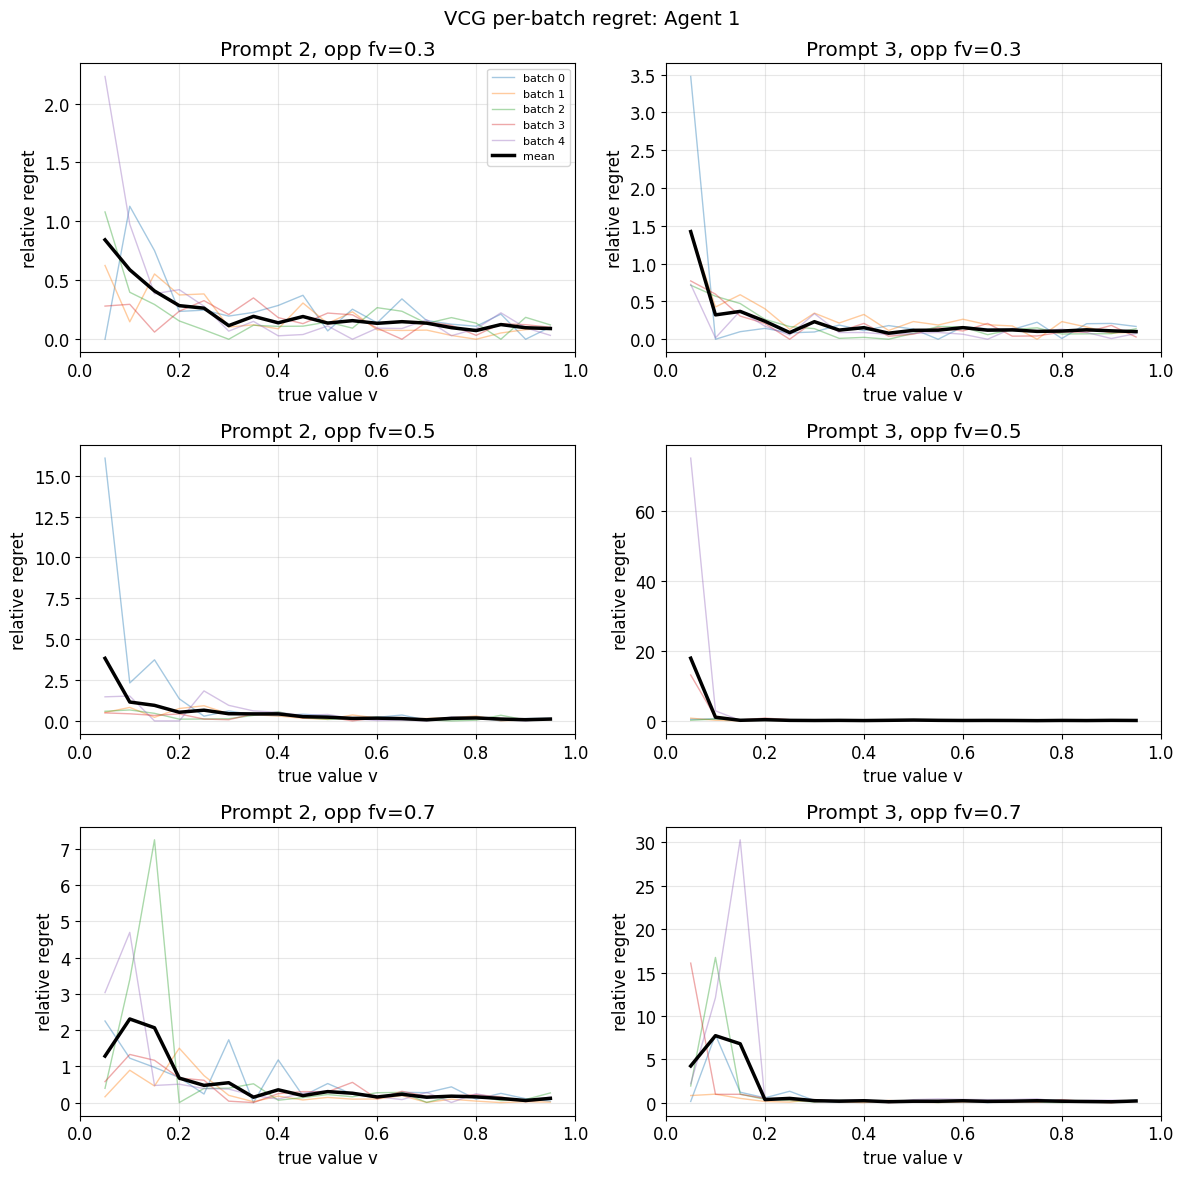

Saved ../results/truthfulness_vcg_25/vcg_regret_batch_a2.png


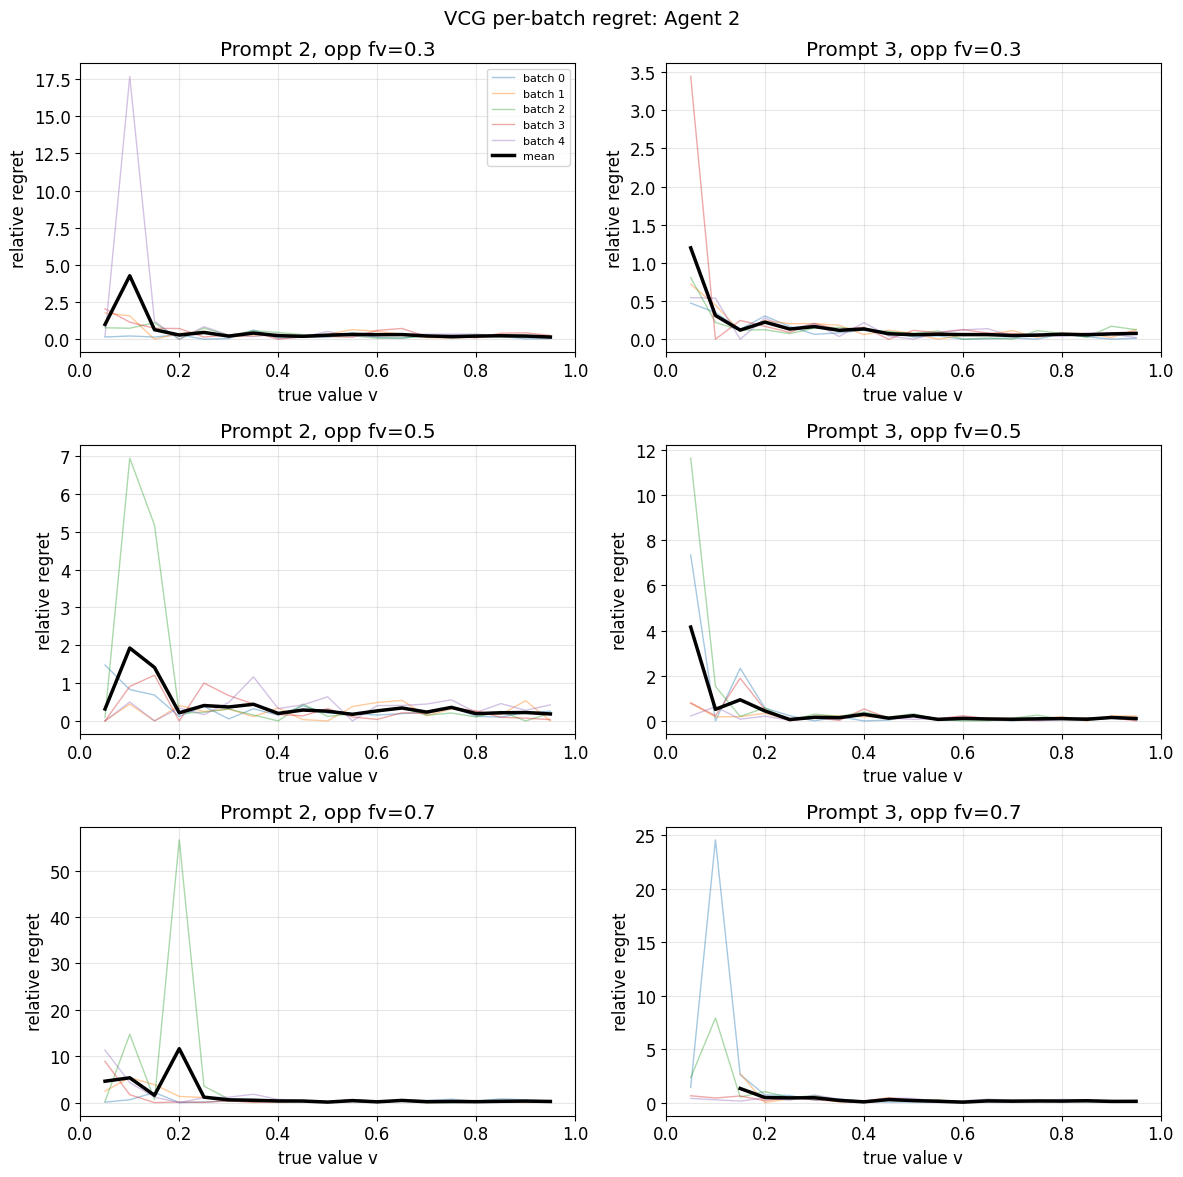

In [11]:
def plot_vcg_regret_per_batch(self_curves, opp_curves, agent_name, save_name):
    """For each (fv, prompt): show the 5 batch-level regret curves + mean (bold black)."""
    if not self_curves or not opp_curves:
        print(f'No curves for {agent_name}')
        return None
    prompt_indices = sorted(set(k[0] for k in self_curves.keys()))
    n_rows = len(FIXED_VALUES)
    n_cols = len(prompt_indices)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows), squeeze=False)
    
    for row, fv in enumerate(FIXED_VALUES):
        for col, pidx in enumerate(prompt_indices):
            ax = axes[row, col]
            key = (pidx, fv)
            if key not in self_curves or key not in opp_curves:
                ax.set_visible(False)
                continue
            self_data = self_curves[key]
            opp_data = opp_curves[key]
            self_batch_fns = self_data['batch_interp_fns']
            opp_batch_fns = opp_data['batch_interp_fns']
            n_b = min(len(self_batch_fns), len(opp_batch_fns))
            if n_b == 0:
                ax.set_visible(False)
                continue
            batch_regrets = []
            for bi in range(n_b):
                rdf = compute_vcg_regret_curve(self_batch_fns[bi], opp_batch_fns[bi],
                                                b_other_fixed=fv, true_values=FINE_TV,
                                                bid_grid=ALL_BIDS)
                ax.plot(rdf['true_value'], rdf['relative_regret'], alpha=0.4, linewidth=1,
                        label=f'batch {bi}' if (row==0 and col==0) else None)
                batch_regrets.append(rdf['relative_regret'].values)
            batch_regrets = np.array(batch_regrets)
            ax.plot(FINE_TV, batch_regrets.mean(axis=0), color='black', linewidth=2.5,
                    label='mean' if (row==0 and col==0) else None)
            ax.set_title(f'Prompt {pidx}, opp fv={fv}')
            ax.set_xlabel('true value v')
            ax.set_ylabel('relative regret')
            ax.set_xlim(0, 1)
            if row == 0 and col == 0:
                ax.legend(fontsize=8)
    
    fig.suptitle(f'VCG per-batch regret: {agent_name}', fontsize=14)
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, save_name)
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()
    return fig

if HAS_DATA and len(df_avg) > 0:
    plot_vcg_regret_per_batch(curves_a1, opp_curves_a1, 'Agent 1', 'vcg_regret_batch_a1.png')
    plot_vcg_regret_per_batch(curves_a2, opp_curves_a2, 'Agent 2', 'vcg_regret_batch_a2.png')


## 9. Export data.csv

In [12]:
def collect_regret_rows(self_curves, opp_curves, agent_label):
    rows = []
    if not self_curves or not opp_curves:
        return rows
    for (pidx, fv), self_data in self_curves.items():
        if (pidx, fv) not in opp_curves:
            continue
        opp_data = opp_curves[(pidx, fv)]
        rdf = compute_vcg_regret_curve(self_data['interp_fn'], opp_data['interp_fn'],
                                        b_other_fixed=fv, true_values=REGRET_TRUE_VALUES,
                                        bid_grid=ALL_BIDS)
        rdf['agent'] = agent_label
        rdf['prompt_idx'] = pidx
        rdf['fixed_val'] = fv
        rows.append(rdf)
    return rows

all_rows = []
if HAS_DATA and len(df_avg) > 0:
    all_rows += collect_regret_rows(curves_a1, opp_curves_a1, 'Agent 1')
    all_rows += collect_regret_rows(curves_a2, opp_curves_a2, 'Agent 2')

if all_rows:
    data_csv = pd.concat(all_rows, ignore_index=True)
    cols = ['agent', 'prompt_idx', 'fixed_val', 'true_value',
            'truthful_utility', 'optimal_utility', 'optimal_bid', 'relative_regret']
    data_csv = data_csv[cols]
    out = os.path.join(RESULTS_DIR, 'data.csv')
    data_csv.to_csv(out, index=False)
    print(f'Saved {len(data_csv)} rows to {out}')
    print(data_csv.head(10))
else:
    data_csv = pd.DataFrame()
    print('No data to export')


Saved 108 rows to ../results/truthfulness_vcg_25/data.csv
     agent  prompt_idx  fixed_val  true_value  truthful_utility  \
0  Agent 1           2        0.3         0.1          0.017148   
1  Agent 1           2        0.3         0.2          0.034355   
2  Agent 1           2        0.3         0.3          0.060059   
3  Agent 1           2        0.3         0.4          0.079336   
4  Agent 1           2        0.3         0.5          0.101387   
5  Agent 1           2        0.3         0.6          0.123193   
6  Agent 1           2        0.3         0.7          0.144766   
7  Agent 1           2        0.3         0.8          0.176455   
8  Agent 1           2        0.3         0.9          0.197871   
9  Agent 1           2        0.5         0.1          0.014482   

   optimal_utility  optimal_bid  relative_regret  
0         0.017148          0.1         0.000000  
1         0.037480          0.3         0.090961  
2         0.060059          0.3         0.000000  


## 10. Summary statistics

In [13]:
if len(data_csv) > 0:
    # Specific point: agent 1, fv=0.3, v=0.5; same for agent 2
    for agent in ['Agent 1', 'Agent 2']:
        sub = data_csv[(data_csv['agent']==agent) & (np.isclose(data_csv['fixed_val'],0.3)) & (np.isclose(data_csv['true_value'],0.5))]
        print(f'\n=== {agent}, opp fv=0.3, v=0.5 ===')
        print(sub[['prompt_idx','truthful_utility','optimal_utility','optimal_bid','relative_regret']].to_string(index=False))
    
    # Summary table: mean & max regret per (agent, fv)
    print('\n=== Mean / Max relative regret per (agent, fv) ===')
    summary = data_csv.groupby(['agent','fixed_val'])['relative_regret'].agg(['mean','max']).reset_index()
    print(summary.to_string(index=False))
    
    print(f'\nTotal rows in data.csv: {len(data_csv)}')



=== Agent 1, opp fv=0.3, v=0.5 ===
 prompt_idx  truthful_utility  optimal_utility  optimal_bid  relative_regret
          2          0.101387         0.105439         0.80         0.039973
          3          0.109062         0.113359         0.45         0.039398

=== Agent 2, opp fv=0.3, v=0.5 ===
 prompt_idx  truthful_utility  optimal_utility  optimal_bid  relative_regret
          2          0.078242         0.083516          0.2         0.067399
          3          0.107598         0.107598          0.5         0.000000

=== Mean / Max relative regret per (agent, fv) ===
  agent  fixed_val     mean      max
Agent 1        0.3 0.059752 0.152875
Agent 1        0.5 0.109123 0.688845
Agent 1        0.7 0.159331 0.700000
Agent 2        0.3 0.057263 0.186686
Agent 2        0.5 0.097085 0.327804
Agent 2        0.7 0.215826 1.528716

Total rows in data.csv: 108


## Focused view: only opponent bid = 0.3

Single-panel regret plots (no allocation, since allocation is identical to the Myerson notebook).
Style matches the bottom subplot of `plot_regret_mean_across_prompts` from the Myerson notebook.

=== Agent 1 (b2 fixed at 0.3) ===


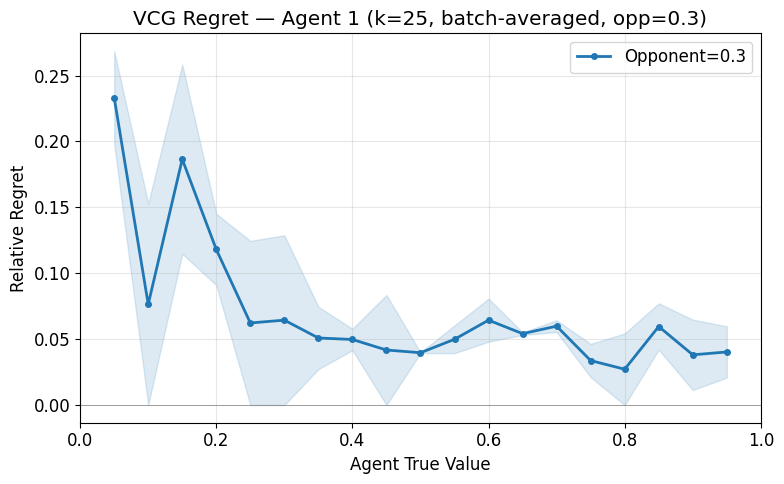

  Prompt 2: mean regret over v∈[0.05,0.95] = 0.0607
  Prompt 3: mean regret over v∈[0.05,0.95] = 0.0814
  Across prompts: mean = 0.0710

=== Agent 2 (b1 fixed at 0.3) ===


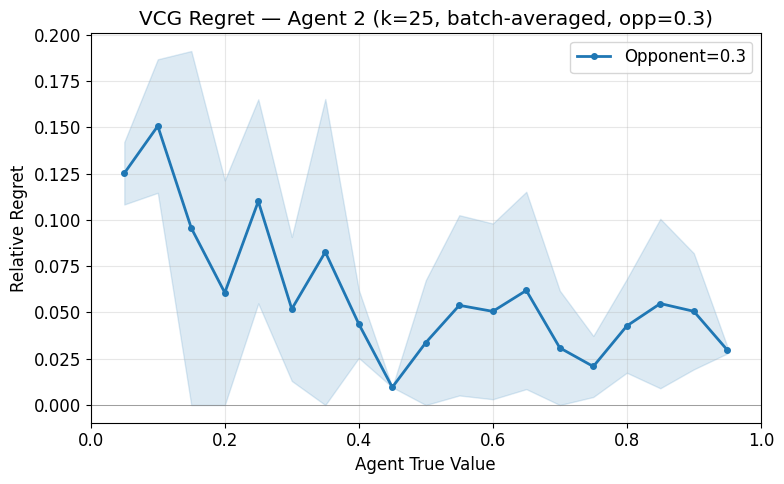

  Prompt 2: mean regret over v∈[0.05,0.95] = 0.0857
  Prompt 3: mean regret over v∈[0.05,0.95] = 0.0363
  Across prompts: mean = 0.0610


In [14]:
FOCUS_FV = 0.3
FINE_TV = np.round(np.arange(0.05, 1.0, 0.05), 2)
MYERSON_COLOR = 'tab:blue'  # matches opp=0.3 color in Myerson notebook

def plot_vcg_regret_only(alloc_curves, opp_curves, agent_name, fixed_val=FOCUS_FV,
                         save_path=None):
    """Single-panel mean-across-prompts VCG regret, only at fixed_val. Matches Myerson style."""
    prompt_keys = [k for k in alloc_curves if k[1] == fixed_val and k in opp_curves]
    if not prompt_keys:
        print(f'No data for {agent_name} at fv={fixed_val}'); return None, {}
    all_regrets = []
    per_prompt_means = {}
    for key in prompt_keys:
        rdf = compute_vcg_regret_curve(
            alloc_curves[key]['interp_fn'],
            opp_curves[key]['interp_fn'],
            b_other_fixed=fixed_val,
            true_values=FINE_TV,
        )
        all_regrets.append(rdf['relative_regret'].values)
        per_prompt_means[key[0]] = rdf['relative_regret'].mean()
    mean_regret = np.mean(all_regrets, axis=0)
    std_regret  = np.std(all_regrets, axis=0)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(FINE_TV, mean_regret, marker='o', color=MYERSON_COLOR,
            label=f'Opponent={fixed_val}', linewidth=2, markersize=4)
    ax.fill_between(FINE_TV, mean_regret - std_regret, mean_regret + std_regret,
                    color=MYERSON_COLOR, alpha=0.15)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Agent True Value')
    ax.set_ylabel('Relative Regret')
    ax.set_title(f'VCG Regret \u2014 {agent_name} (k=25, batch-averaged, opp={fixed_val})')
    ax.set_xlim(0.0, 1.0)
    ax.legend()
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig, per_prompt_means

print('=== Agent 1 (b2 fixed at 0.3) ===')
fig_a1, pp_a1 = plot_vcg_regret_only(curves_a1, opp_curves_a1, 'Agent 1', FOCUS_FV,
    save_path=os.path.join(RESULTS_DIR, 'vcg_regret_only_a1_fv0.3.png'))
plt.show()
for pidx, m in sorted(pp_a1.items()):
    print(f'  Prompt {pidx}: mean regret over v\u2208[0.05,0.95] = {m:.4f}')
if pp_a1:
    print(f'  Across prompts: mean = {np.mean(list(pp_a1.values())):.4f}')

print()
print('=== Agent 2 (b1 fixed at 0.3) ===')
fig_a2, pp_a2 = plot_vcg_regret_only(curves_a2, opp_curves_a2, 'Agent 2', FOCUS_FV,
    save_path=os.path.join(RESULTS_DIR, 'vcg_regret_only_a2_fv0.3.png'))
plt.show()
for pidx, m in sorted(pp_a2.items()):
    print(f'  Prompt {pidx}: mean regret over v\u2208[0.05,0.95] = {m:.4f}')
if pp_a2:
    print(f'  Across prompts: mean = {np.mean(list(pp_a2.values())):.4f}')


### Per-prompt VCG regret (agent 1 only, agent 2 fixed at 0.3)

One panel per prompt, single blue line per panel, no shading. Matches the bottom-subplot style of `plot_regret_mean` in the Myerson notebook.

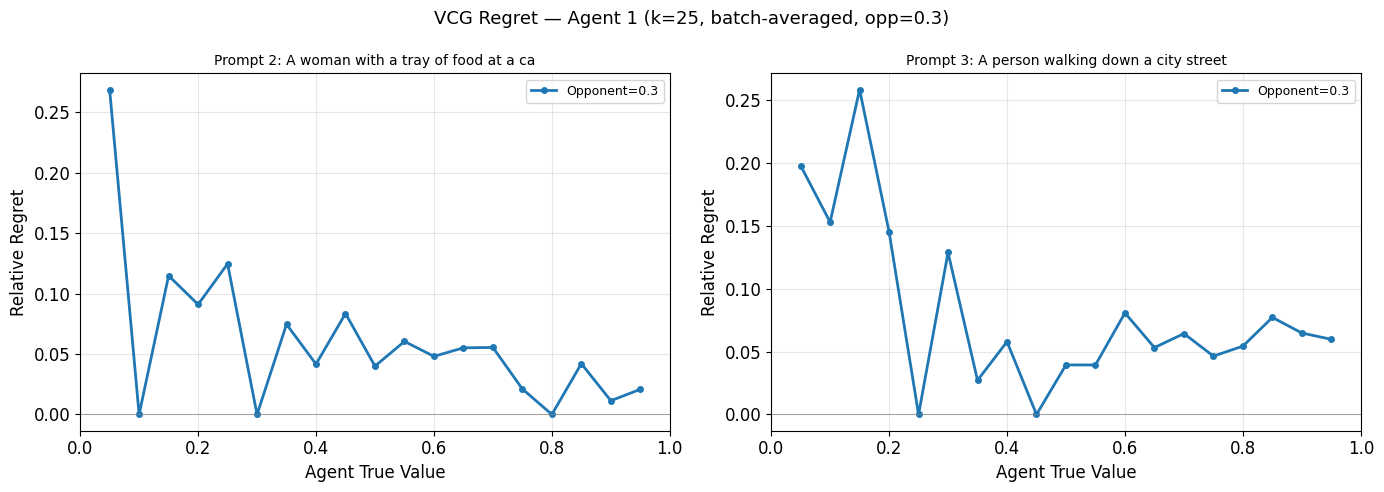

Mean VCG regret per prompt (Agent 1, opp=0.3, v∈[0.05,0.95]):
  Prompt 2: 0.0607
  Prompt 3: 0.0814
  Across prompts: mean = 0.0710


In [15]:
FOCUS_FV = 0.3
FINE_TV  = np.round(np.arange(0.05, 1.0, 0.05), 2)
with open('../prompts/truthfulness_regular.json') as _f:
    PROMPTS_TR = json.load(_f)

def plot_vcg_regret_per_prompt_a1(alloc_curves, opp_curves, prompts, fixed_val=FOCUS_FV,
                                  save_path=None):
    keys = sorted([k for k in alloc_curves if k[1] == fixed_val and k in opp_curves])
    if not keys:
        print(f'No data at fv={fixed_val}'); return None, {}
    fig, axes = plt.subplots(1, len(keys), figsize=(7*len(keys), 5), squeeze=False)
    per_prompt_means = {}
    for col, key in enumerate(keys):
        pidx, fv = key
        rdf = compute_vcg_regret_curve(
            alloc_curves[key]['interp_fn'],
            opp_curves[key]['interp_fn'],
            b_other_fixed=fv,
            true_values=FINE_TV,
        )
        per_prompt_means[pidx] = rdf['relative_regret'].mean()
        ax = axes[0, col]
        ax.plot(rdf['true_value'], rdf['relative_regret'],
                marker='o', color='tab:blue',
                label=f'Opponent={fv}', linewidth=2, markersize=4)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='-')
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel('Agent True Value')
        ax.set_ylabel('Relative Regret')
        ax.set_title(f'Prompt {pidx}: {prompts[pidx]["base_prompt"][:35]}', fontsize=10)
        ax.legend(fontsize=9)
    fig.suptitle(f'VCG Regret \u2014 Agent 1 (k=25, batch-averaged, opp={fixed_val})', fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig, per_prompt_means

fig, pp = plot_vcg_regret_per_prompt_a1(
    curves_a1, opp_curves_a1, PROMPTS_TR, FOCUS_FV,
    save_path=os.path.join(RESULTS_DIR, 'vcg_regret_per_prompt_a1_fv0.3.png'),
)
plt.show()

print('Mean VCG regret per prompt (Agent 1, opp=0.3, v\u2208[0.05,0.95]):')
for pidx, m in sorted(pp.items()):
    print(f'  Prompt {pidx}: {m:.4f}')
if pp:
    print(f'  Across prompts: mean = {np.mean(list(pp.values())):.4f}')
